In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Generate fictive data

In [2]:
# reproducibility
set.seed(72397)

# Data generating parameters
N    <- 250 # Number of samples
mu   <- 40  # Mean of gaussian component
sd   <- 4   # Standard deviation of gaussian component
rate <- 0.5 # Rate of the exponential component

# Speeds a are roughly normal but with a longer right tail.
# This is an "Exponentially modified Gaussian distribution"
speeds <- rnorm(n = N, mean = mu, sd = sd) + rexp(n = N, rate = rate)

# Store in a data frame with a single column "speed"
df <- data.frame("speed"=speeds)

### Step 1: Plot a Basic Histogram

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


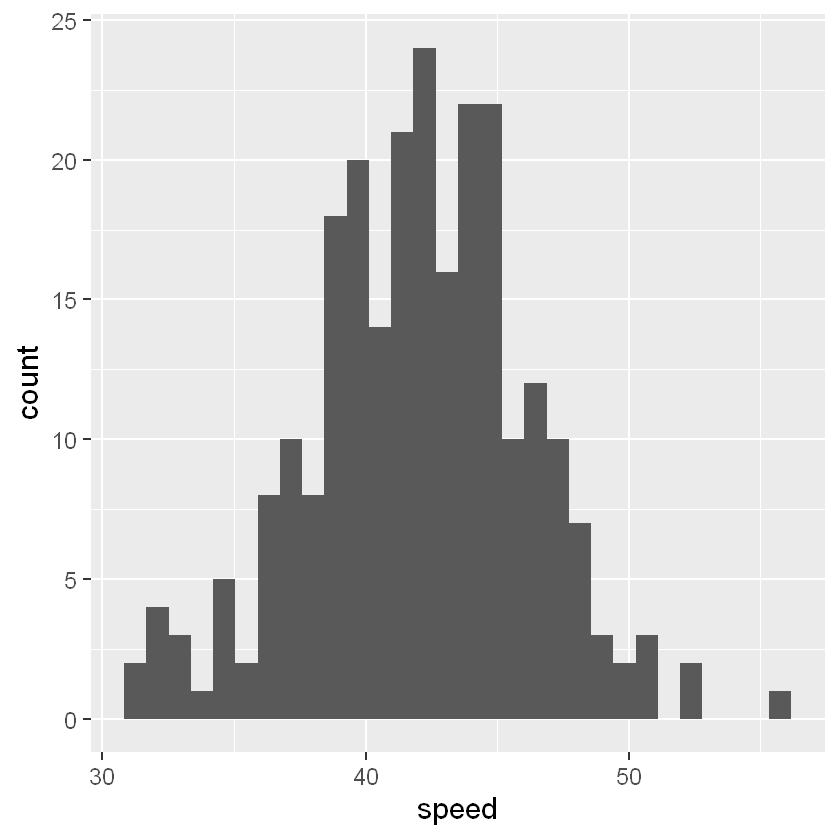

In [3]:
p <- ggplot(data=df, aes(x=speed)) +
    geom_histogram() +
    theme_gray(base_size=18)
p

### Step 2: Adjust bin width, scales, and labels

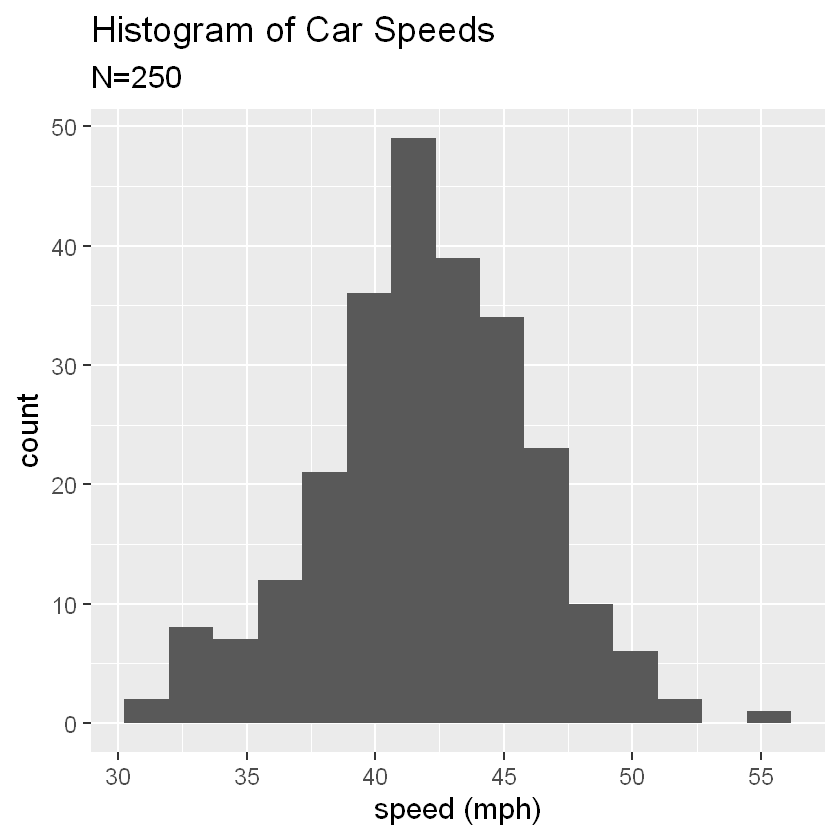

In [4]:
# Freedman-Diaconis rule
get_binwidth <- function(x){
    return((2 * IQR(x)) / length(x)**(1/3))
}

p <- ggplot(data=df, aes(x=speed)) +
         geom_histogram(binwidth = get_binwidth, aes(y=after_stat(count))) +

         # Scales & Labels
         scale_x_continuous(breaks = seq(from = 30, to = 60, by = 5)) +
         labs(x="speed (mph)", title = "Histogram of Car Speeds", subtitle= "N=250") +
         theme_gray(base_size=18)
p

### Step 3: Add reference lines

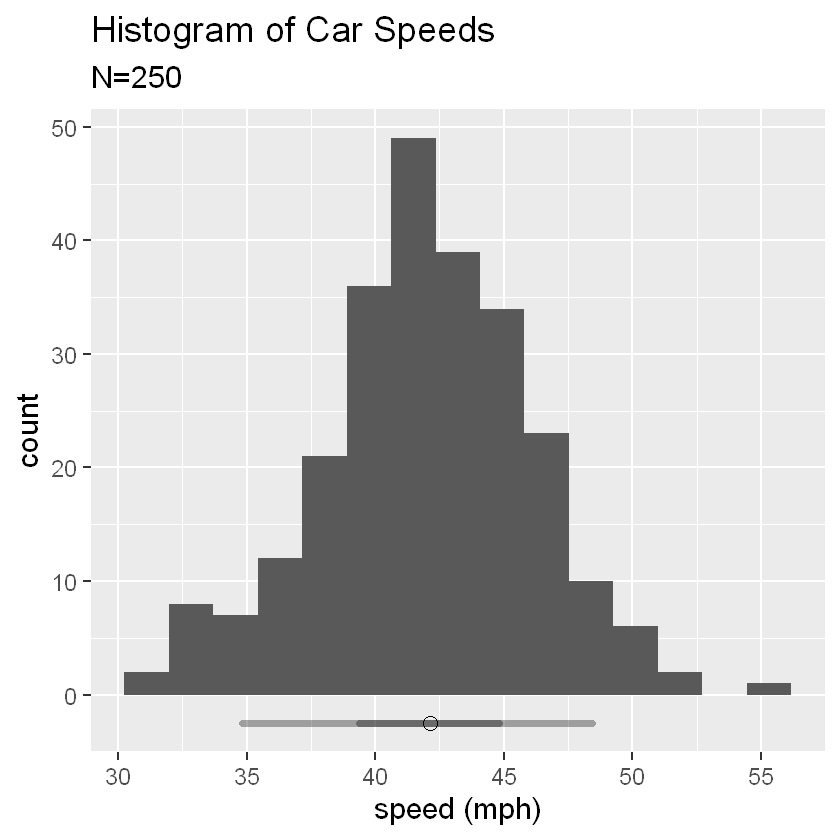

In [5]:
GeomLinerange$default_aes$linewidth <- 2

quantile_df <- function(x, probs){
    summary_df <- data.frame("ymin"=quantile(x, probs[1]),
                             "ymax"=quantile(x, probs[2]))
    return(summary_df)
}

p <- ggplot(data=df, aes(x=speed)) +
         geom_histogram(binwidth = get_binwidth, aes(y=after_stat(count))) +

         # Scales
         scale_x_continuous(breaks = seq(from = 30, to = 60, by = 5)) + 
         labs(x="speed (mph)", title = "Histogram of Car Speeds", subtitle= "N=250") +
         theme_gray(base_size=18) +

         # Uncertainty/Error & central tendency
         stat_summary(fun.data = quantile_df, geom ="linerange", 
             aes(x = speed, y = -2.5),
             orientation = "y", fun.args = list("probs"=c(.05,.95)), alpha=0.33, lineend="round") + # outer

         stat_summary(fun.data = quantile_df, geom ="linerange", 
             aes(x = speed, y = -2.5),
             orientation = "y", fun.args = list("probs"=c(.25,.75)), alpha=0.33, lineend="round")+  # inner

         stat_summary(fun = median, geom ="point", # point
             aes(x = speed, y = -2.5),
             orientation = "y", col="black", shape=21, size=4)
p

### Step 4: Colour and fill

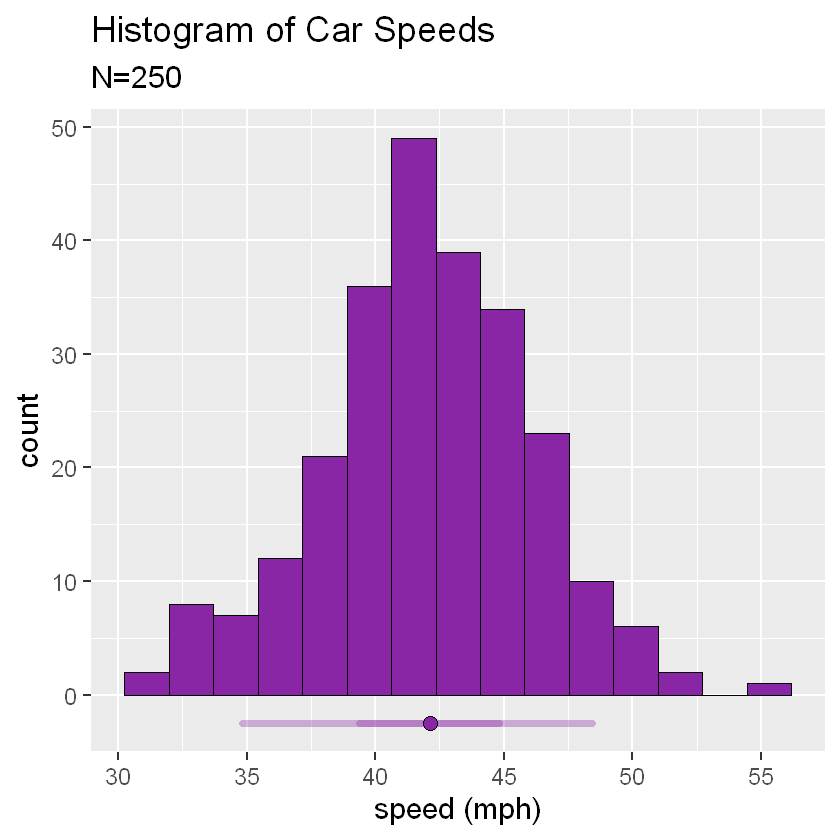

In [6]:
p <- ggplot(data=df, aes(x=speed)) +
         # Histogram
         geom_histogram(binwidth = get_binwidth, col="black", fill="#8826A6", aes(y=after_stat(count))) +

         # Scales & lables
         scale_x_continuous(breaks = seq(from = 30, to = 60, by = 5)) + 
         labs(x="speed (mph)", title = "Histogram of Car Speeds", subtitle = "N=250") +
         theme_gray(base_size=18) +

         # Uncertainty
         stat_summary(fun.data = quantile_df, geom ="linerange", 
             aes(x = speed, y = -2.5),
             orientation = "y", fun.args = list("probs"=c(.05,.95)), col="#8826A6", alpha=0.33, lineend="round") + # outer

         stat_summary(fun.data = quantile_df, geom ="linerange", 
             aes(x = speed, y = -2.5),
             orientation = "y", fun.args = list("probs"=c(.25,.75)), col="#8826A6", alpha=0.33, lineend="round")+  # inner

         stat_summary(fun = median, geom ="point", # point
             aes(x = speed, y = -2.5),
             orientation = "y", col="black", fill="#8826A6", shape=21, size=4)
p
ggsave(plot = p, filename = "my_histogram.png", width = 2560/300, height = 1440/300, units = "in", dpi=300)